In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy  as np
import json, os, math, datetime
from sklearn.linear_model import LinearRegression
from Metrics.CrossValidation.index import CrossValidation
from Metrics.Plotter.index import Plotter
pd.set_option('display.max_columns', None)

In [2]:
TEST    = json.loads(open('../../info.json', 'r').read()).get('test', 1)
SOURCE  = f'../../Dataset/test{TEST}/files/data.csv'
DATASET = 'Backup/target.csv'
RESULTS = f'../../Dataset/test{TEST}/results'

print('SOURCE:', SOURCE)

SOURCE: ../../Dataset/test1/files/data.csv


# IMPORTANDO DADOS
Saída do ensaio de pêndulo: cada amostra traz a IMU em teste (`target_`) e a MRU de referência (`ref_`) já alinhadas no mesmo instante.

In [3]:
df = pd.read_csv(SOURCE)
print(len(df), 'linhas')
df.head()

1801 linhas


,time,target_wz,target_tmp,target_pitch,target_e,target_ay,target_ax,target_wx,target_wy,target_az,target_roll,target_yaw,static,ref_sample_time,ref_wz,ref_pitch,ref_q0,ref_q1,ref_ay,ref_wx,ref_ax,ref_q2,ref_wy,ref_la_pos_mon_d,ref_az,ref_roll,ref_yaw,ref_q3
0,0.0,-6.92455,53.0,-1.525,-22.176,10.733555,0.194623,-47.92960,-1.16726,-0.614769,18.043,2.936,False,605000000.0,0.200478,0.304871,-0.8118,0.5835,9.59,-44.581846,0.06400,0.01196,0.471315,-0.5252,0.8262,-71.390541,2.771970,-0.02120
1,0.1,-8.13221,52.9,-0.742,-16.704,11.618576,0.294719,-58.13591,-1.05996,-0.532550,12.732,2.725,False,705000000.0,0.165413,0.337243,-0.7843,0.6199,10.54,-54.981030,0.09128,0.01243,0.546086,-0.4685,0.8149,-76.661753,2.723841,-0.02047
2,0.2,-8.42212,53.1,0.119,-10.440,12.899422,0.256924,-67.53252,-1.95110,-2.312996,6.586,2.578,False,805000000.0,0.189592,0.366750,-0.7505,0.6604,11.46,-62.337808,0.12330,0.01297,0.585563,-0.4231,0.7793,-82.677810,2.667691,-0.01959
3,0.3,-9.92099,53.3,1.010,-3.240,12.406766,0.425020,-67.39252,-1.05936,-0.455019,-0.016,2.655,False,905000000.0,0.310085,0.387721,-0.7116,0.7021,12.17,-66.291217,0.19090,0.01440,-1.635795,-0.3990,0.7029,-89.209529,2.743322,-0.01942
4,0.4,-9.44709,52.9,1.984,3.744,12.362390,0.271203,-66.62502,-1.97845,-0.208931,-6.779,2.656,False,5000000.0,0.653172,0.442381,-0.6696,0.7424,12.51,-66.806879,0.17590,0.01442,0.789536,-0.4016,0.5932,-95.913135,2.624720,-0.01821


# DEFASAGEM
- Atraso da IMU em teste contra a MRU de referência: pico da correlação cruzada do roll, só no trecho em movimento (`static` falso)
- Todas as colunas `target_` andam juntas, sem atravessar o buraco da gravação; as amostras que ficam sem par saem

In [4]:
# ATRASO DA IMU EM TESTE CONTRA A REFERÊNCIA PELO PICO DA CORRELAÇÃO CRUZADA
class Phaser:
    def __init__(self, target, reference):
        self.target    = target
        self.reference = reference

    def get(self, df, var):
        if df.empty:
            return 0

        x = df[self.target + var]
        y = df[self.reference + var]

        correlation = np.correlate(y - y.mean(), x - x.mean(), mode='full')
        lags = np.arange(-len(df) + 1, len(df))
        return lags[np.argmax(correlation)]

    def set(self, df, lag):
        columns = df.filter(regex=f'^{self.target}').columns
        step    = df.time.diff()
        block   = (step > 1.5*step.median()).cumsum()    # O DESLOCAMENTO NÃO ATRAVESSA O BURACO DA GRAVAÇÃO

        df[columns] = df.groupby(block)[columns].shift(lag)
        return df.dropna(subset=columns).reset_index(drop=True)


phaser = Phaser('target_', 'ref_')
lag    = phaser.get(df[~df.static], 'roll')
df     = phaser.set(df, lag)
print('defasagem:', lag, 'amostras |', len(df), 'linhas')

defasagem: 0 amostras | 1801 linhas


# RENOMEANDO COLUNAS

In [5]:
ANGLES  = ['pitch', 'roll', 'yaw']

columns = {f'target_{var}': var for var in ANGLES} | {f'ref_{var}': f'ref_{var}' for var in ANGLES} 
df = df[['time', 'static'] + list(columns)].rename(columns=columns)
df

,time,static,pitch,roll,yaw,ref_pitch,ref_roll,ref_yaw
0,0.0,False,-1.525,18.043,2.936,0.304871,-71.390541,2.771970
1,0.1,False,-0.742,12.732,2.725,0.337243,-76.661753,2.723841
2,0.2,False,0.119,6.586,2.578,0.366750,-82.677810,2.667691
3,0.3,False,1.010,-0.016,2.655,0.387721,-89.209529,2.743322
4,0.4,False,1.984,-6.779,2.656,0.442381,-95.913135,2.624720
...,...,...,...,...,...,...,...,...
1796,279.5,True,1.368,-2.509,5.289,1.645535,-92.131613,6.371291
1797,279.6,True,1.367,-2.506,5.291,1.644962,-92.131613,6.371291
1798,279.7,True,1.367,-2.506,5.289,1.645535,-92.131613,6.377020
1799,279.8,True,1.367,-2.504,5.290,1.644962,-92.131613,6.377020


# PERÍODO DE AMOSTRAGEM
- Verificando a distribuição do período para verificar número de outliers

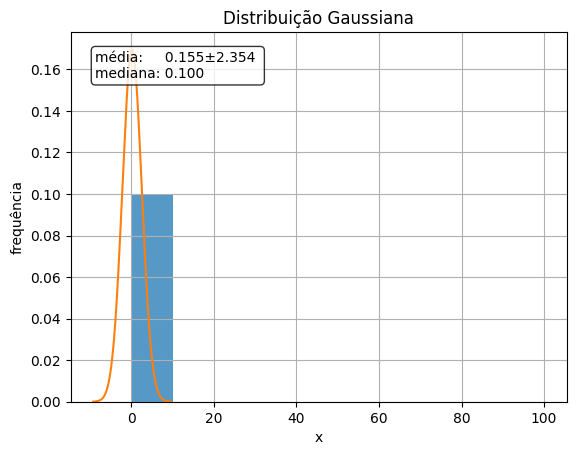

2799 amostras na grade de 0.1 s


,time,static,pitch,roll,yaw,ref_pitch,ref_roll,ref_yaw
0,0.0,False,-1.525,18.043,2.936,0.304871,-71.390541,2.771970
1,0.1,False,-0.742,12.732,2.725,0.337243,-76.661753,2.723841
2,0.2,False,0.119,6.586,2.578,0.366750,-82.677810,2.667691
3,0.3,False,1.010,-0.016,2.655,0.387721,-89.209529,2.743322
4,0.4,False,1.984,-6.779,2.656,0.442381,-95.913135,2.624720
...,...,...,...,...,...,...,...,...
2794,279.4,True,1.368,-2.510,5.289,1.644962,-92.131613,6.371291
2795,279.5,True,1.368,-2.509,5.289,1.645535,-92.131613,6.371291
2796,279.6,True,1.367,-2.506,5.291,1.644962,-92.131613,6.371291
2797,279.7,True,1.367,-2.506,5.289,1.645535,-92.131613,6.377020


In [6]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)

    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()

# GRADE E LEITURAS ARREDONDADAS NA MESMA CASA: SEM ISSO O RUÍDO DE FLOAT (1e-14) FAZ O merge_asof SEGURAR A AMOSTRA ANTERIOR
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = (df[key] - df[key].iloc[0]).round(10)

    n = int(np.floor(df[key].iloc[-1] / dt)) + 1
    newAxis = np.round(np.linspace(0, dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    return pd.merge_asof(target, df, on=key, direction='backward')


time = df.time.diff()[1:].to_numpy()
dt   = 0.1

gaussian(time); plt.show()
df = normalizePeriod(df, 'time', dt)
print(len(df), 'amostras na grade de', dt, 's')
df

# VISUALIZAÇÃO DOS DADOS

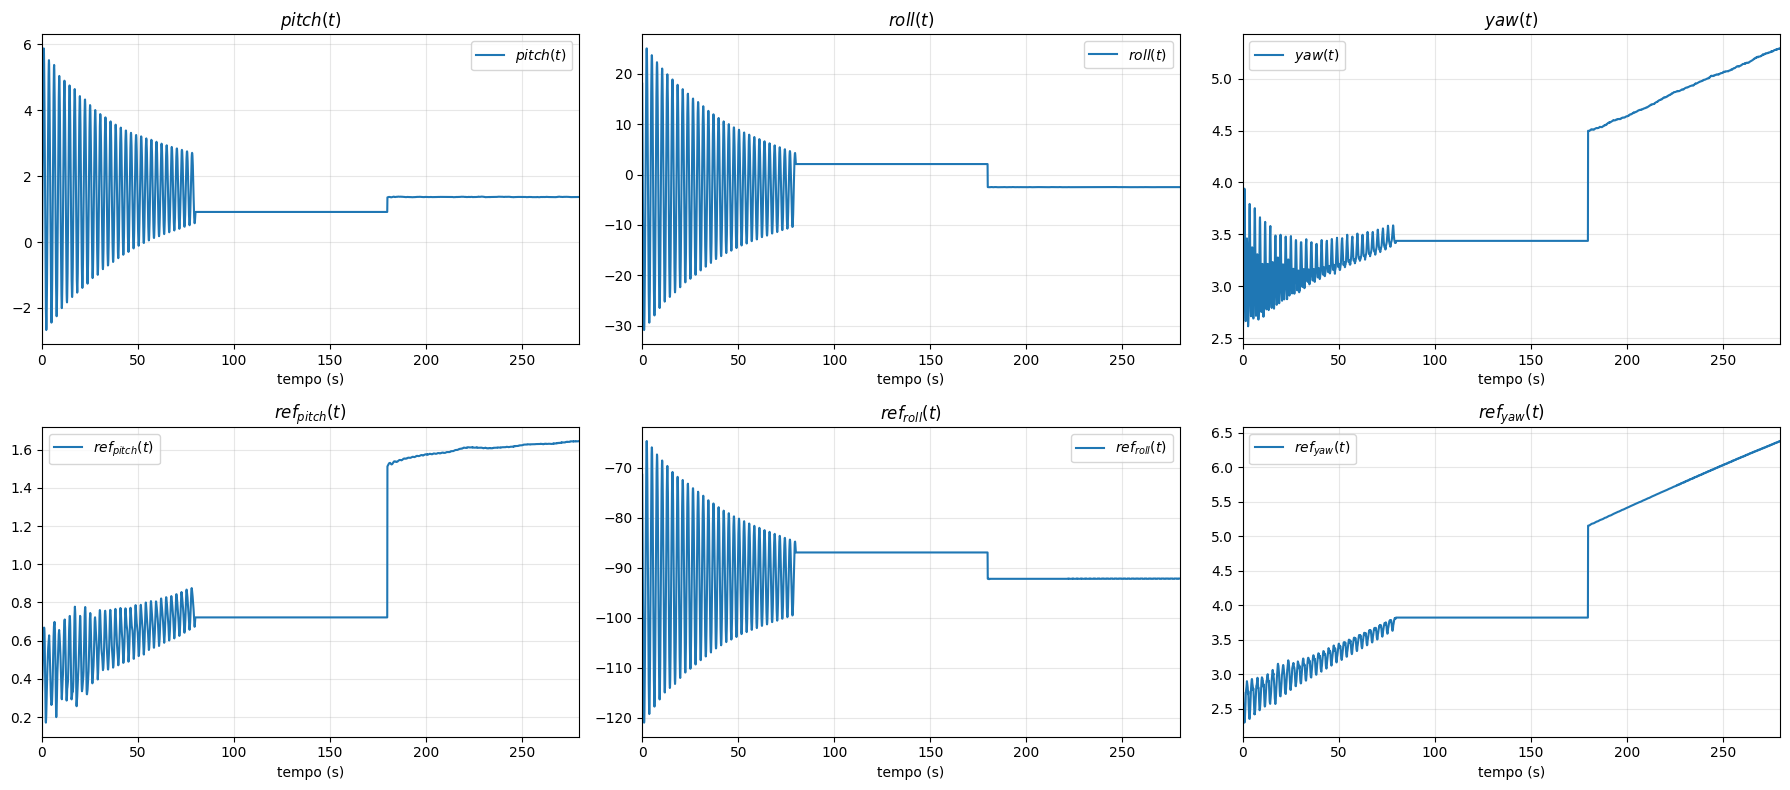

In [7]:
# GRADE DE SUBPLOTS RECORTADA POR FRAÇÃO DO TEMPO TOTAL
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = (t_max - t_min)

    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])

    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)

        plt.subplot(numRows, numCols, i+1)
        plt.plot(time[mask], values[mask], label=key)

        plt.xlim(start_time, end_time)
        if yLim: plt.ylim(yLim)
        plt.title(key); plt.xlabel('tempo (s)')
        plt.grid(alpha=0.3); plt.legend()

    plt.tight_layout()
    plt.show()


# PAINEL PADRÃO: OS ÂNGULOS DO SENSOR E OS DA REFERÊNCIA
def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw,
        '$ref_{pitch}(t)$': df.ref_pitch, '$ref_{roll}(t)$': df.ref_roll, '$ref_{yaw}(t)$': df.ref_yaw
    }, limits)


plotAll(df, limits=(0, 1))

# SALVANDO DADOS

In [8]:
os.makedirs('Backup', exist_ok=True)

df.to_csv(DATASET, index=None)
pd.read_csv(DATASET).head()

,time,static,pitch,roll,yaw,ref_pitch,ref_roll,ref_yaw
0,0.0,False,-1.525,18.043,2.936,0.304871,-71.390541,2.771970
1,0.1,False,-0.742,12.732,2.725,0.337243,-76.661753,2.723841
2,0.2,False,0.119,6.586,2.578,0.366750,-82.677810,2.667691
3,0.3,False,1.010,-0.016,2.655,0.387721,-89.209529,2.743322
4,0.4,False,1.984,-6.779,2.656,0.442381,-95.913135,2.624720


In [9]:
xCols = ANGLES
yCols = [f'ref_{var}' for var in ANGLES]

full = df[(df[xCols + yCols].diff() != 0).any(axis=1)].reset_index(drop=True)    # FORA O BURACO QUE A GRADE PREENCHEU: LINHA IGUAL À ANTERIOR EM TUDO
df   = full.loc[~full.static]    # O AJUSTE SÓ VÊ O BALANÇO; O REPOUSO VOLTA NA HORA DE SALVAR

df

,time,static,pitch,roll,yaw,ref_pitch,ref_roll,ref_yaw
0,0.0,False,-1.525,18.043,2.936,0.304871,-71.390541,2.771970
1,0.1,False,-0.742,12.732,2.725,0.337243,-76.661753,2.723841
2,0.2,False,0.119,6.586,2.578,0.366750,-82.677810,2.667691
3,0.3,False,1.010,-0.016,2.655,0.387721,-89.209529,2.743322
4,0.4,False,1.984,-6.779,2.656,0.442381,-95.913135,2.624720
...,...,...,...,...,...,...,...,...
795,79.5,False,0.571,4.234,3.426,0.672652,-84.797754,3.813607
796,79.6,False,0.571,4.281,3.422,0.674944,-84.740458,3.810742
797,79.7,False,0.634,3.920,3.416,0.688695,-85.084233,3.803294
798,79.8,False,0.747,3.169,3.432,0.702446,-85.829078,3.818764


# CORRELAÇÃO COM A REFERÊNCIA
- Cada ângulo do sensor contra o mesmo ângulo da referência: o ajuste por eixo só serve onde a nuvem é uma reta

/tmp/ipykernel_60982/93330830.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.grid(alpha=.3); plt.legend()


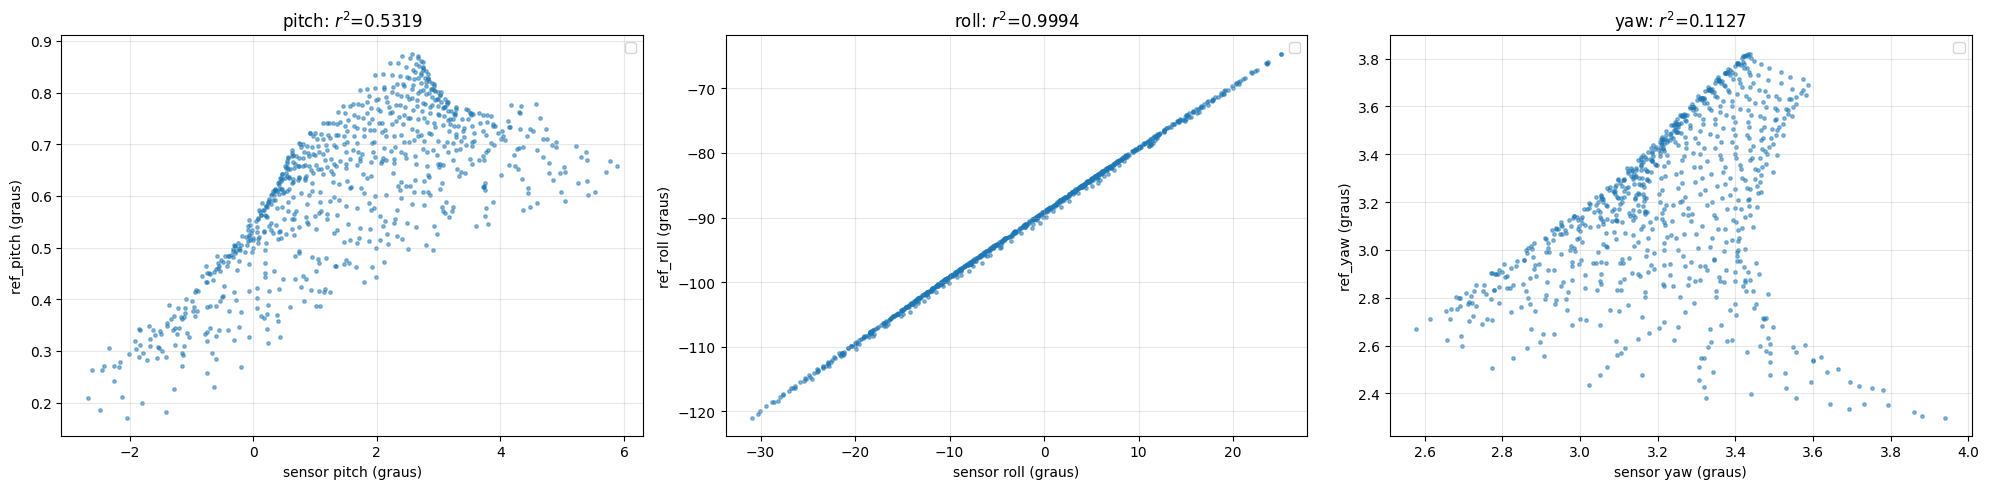

In [10]:
plt.figure(figsize=(20, 5))

for i, (xCol, yCol) in enumerate(zip(xCols, yCols)):
    corr = np.corrcoef(df[xCol], df[yCol])[0, 1]
    plt.subplot(1, 3, i + 1)
    plt.scatter(df[xCol], df[yCol], s=6, alpha=.5)

    plt.title(f'{xCol}: $r^2$={corr**2:.4f}'); plt.xlabel(f'sensor {xCol} (graus)'); plt.ylabel(f'{yCol} (graus)')
    plt.grid(alpha=.3); plt.legend()

plt.tight_layout()
plt.show()

# AJUSTE LINEAR
Cada ângulo da referência é uma combinação linear dos ângulos do sensor, ajustada por mínimos quadrados:

$$\hat{y} = M\,x + B, \qquad x = [\,pitch,\ roll,\ yaw\,]^\top$$

- **Por eixo** ($M$ diagonal): escala e viés de cada ângulo, a calibração clássica
- **Matriz cheia** ($M$ 3×3): também o acoplamento entre eixos que a montagem desalinhada cria
- O R² vem da validação cruzada em blocos contíguos intercalados, a mesma do MachineLearning: toda dobra testa balanço e repouso

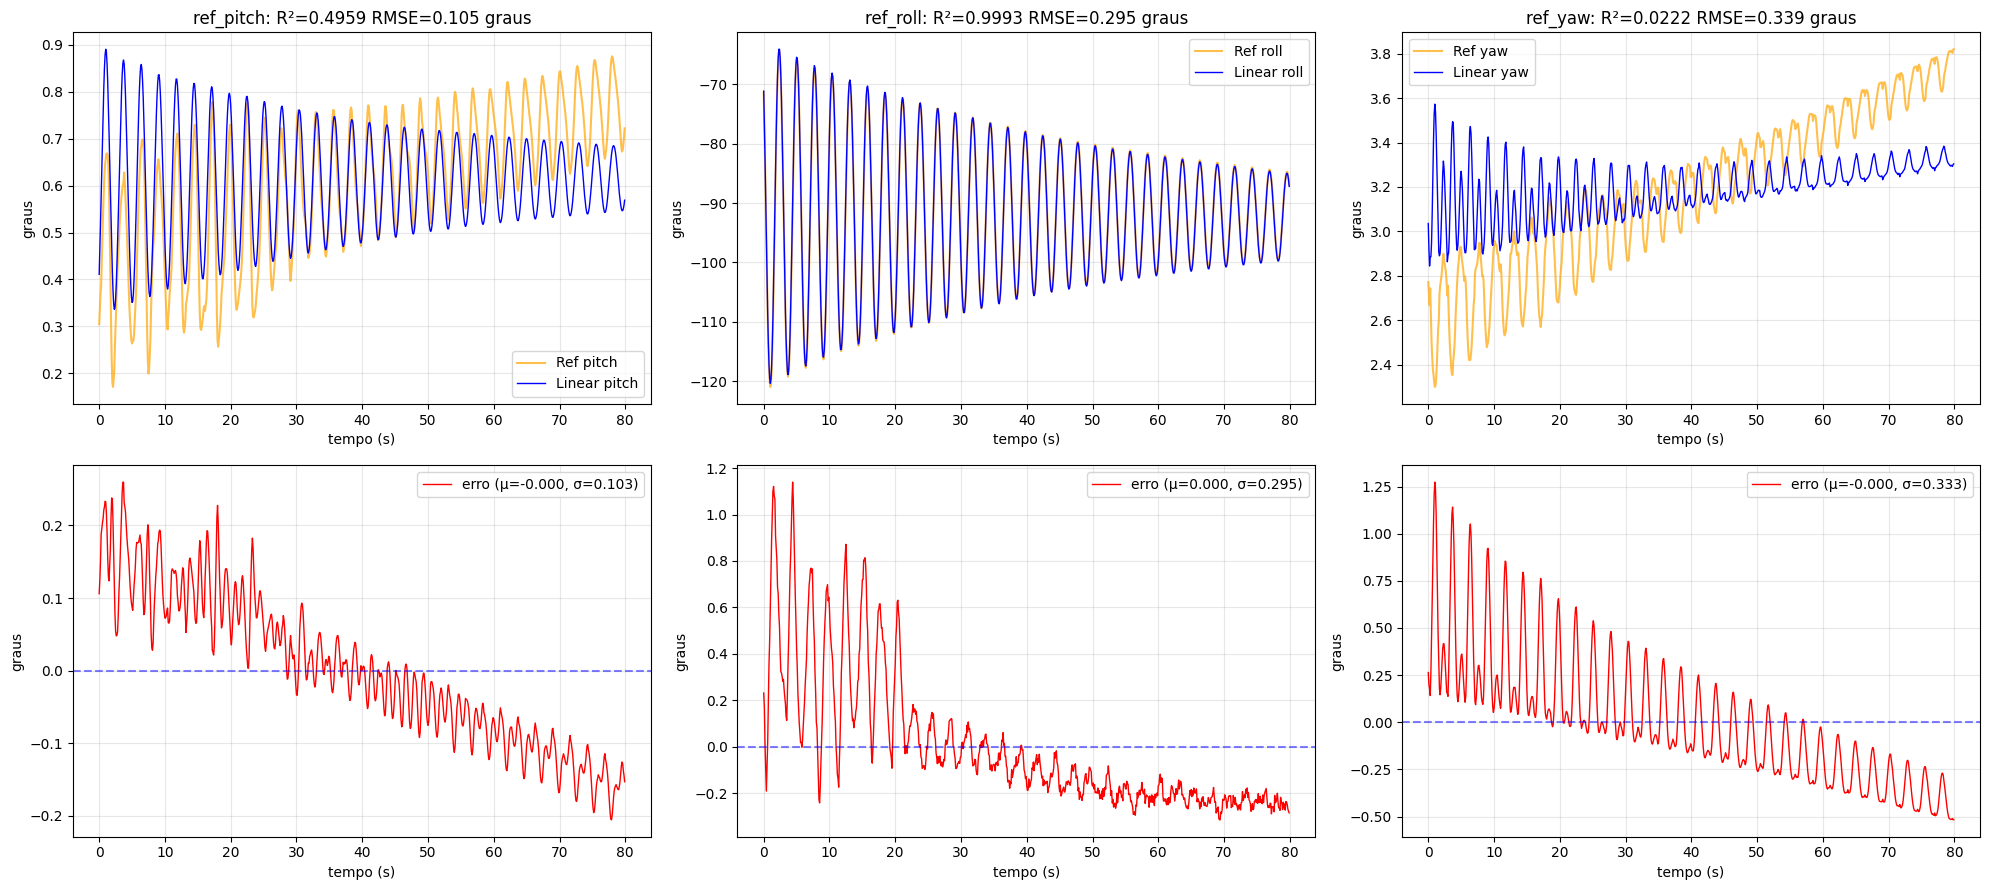

In [11]:
class LinearFit:
    K_CV = 5 

    def __init__(self, df, xCols, yCols, fuse=False):
        self.df    = df
        self.xCols = xCols
        self.yCols = yCols
        self.fuse  = fuse

    def update(self):
        size   = len(self.xCols)
        self.M = np.zeros((size, size))
        self.B = np.zeros(size)
        self.cross = {}

        for i, yCol in enumerate(self.yCols):
            inputs = list(range(size)) if self.fuse else [i]
            xData  = self.df[[self.xCols[j] for j in inputs]]
            yData  = self.df[yCol].to_numpy()

            model = LinearRegression().fit(xData, yData)
            self.M[i, inputs] = model.coef_
            self.B[i]         = model.intercept_

            self.cross[yCol] = CrossValidation(model, xData, yData, self.K_CV)
            self.cross[yCol].update()

        self.yModel = self.df[self.xCols].to_numpy() @ self.M.T + self.B
        self.errors = self.yModel - self.df[self.yCols].to_numpy()

    def get(self):
        return {yCol: cross.info() for yCol, cross in self.cross.items()}

    def info(self):
        return {yCol: {**dict(zip(self.xCols, self.M[i].round(6).tolist())), 'bias': round(float(self.B[i]), 6)} for i, yCol in enumerate(self.yCols)}

    def display(self):
        display(pd.DataFrame(self.info()).T.join(pd.DataFrame(self.get()).T))

    def plot(self, save=None):
        plt.figure(figsize=(20, 9))
        metrics = self.get()
        step    = self.df.time.diff()
        time    = self.df.time.mask(step > 1.5*step.median())    # NaN NO BURACO: A LINHA NÃO LIGA 80 s A 180 s

        for i, (xCol, yCol) in enumerate(zip(self.xCols, self.yCols)):
            error = self.errors[:, i]

            plt.subplot(2, 3, i + 1)
            plt.plot(time, self.df[yCol], label=f'Ref {xCol}', color='orange', alpha=.7)
            plt.plot(time, self.yModel[:, i], label=f'Linear {xCol}', color='blue', linewidth=1)
            plt.title(f'{yCol}: R²={metrics[yCol]["r2"]:.4f} RMSE={metrics[yCol]["rmse"]:.3f} graus')
            plt.xlabel('tempo (s)'); plt.ylabel('graus'); plt.grid(alpha=.3); plt.legend()

            plt.subplot(2, 3, i + 4)
            plt.plot(time, error, label=f'erro (µ={error.mean():.3f}, σ={error.std():.3f})', color='red', linewidth=1)
            plt.axhline(0, color='blue', linestyle='--', alpha=.5)
            plt.xlabel('tempo (s)'); plt.ylabel('graus'); plt.grid(alpha=.3); plt.legend()

        plt.tight_layout()
        if save: plt.savefig(save, dpi=110, bbox_inches='tight')
        plt.show()


fit = LinearFit(df, xCols, yCols)
fit.update()
fit.plot()

# ESCOLHA DO AJUSTE
- A matriz cheia só fica se ganhar no R² médio da validação cruzada

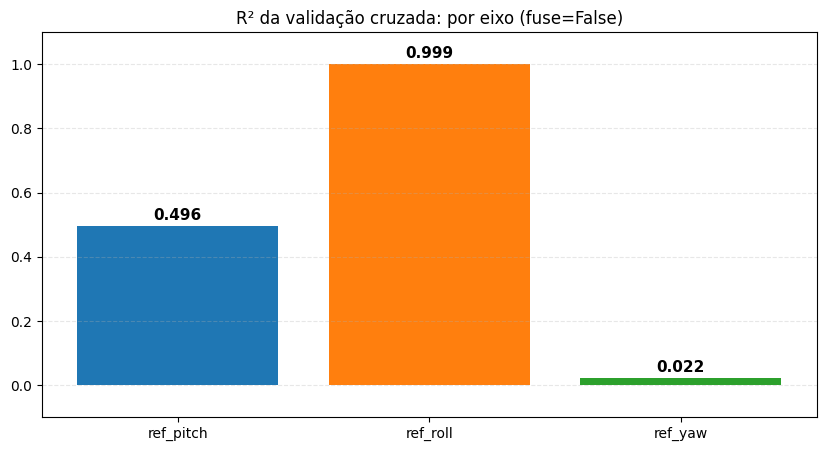

In [12]:
fit = LinearFit(df, xCols, yCols, fuse=False)
fit.update()

score = {yCol: metric['r2'] for yCol, metric in fit.get().items()}
bottom = min(0, *score.values()) - 0.1

plt.figure(figsize=(10, 5)) 
Plotter(score, limits=(bottom, 1.1), title='R² da validação cruzada: por eixo (fuse=False)')
plt.show()

# VISUALIZAÇÃO FINAL

,pitch,roll,yaw,bias,r2,r2_adj,rmse,mae
ref_pitch,0.064796,0.00000,0.000000,0.509697,0.495876,0.492686,0.105027,0.087405
ref_roll,0.000000,1.00494,0.000000,-89.291410,0.999344,0.999340,0.295082,0.223951
ref_yaw,0.000000,0.00000,0.535418,1.463621,0.022181,0.015992,0.339230,0.260603


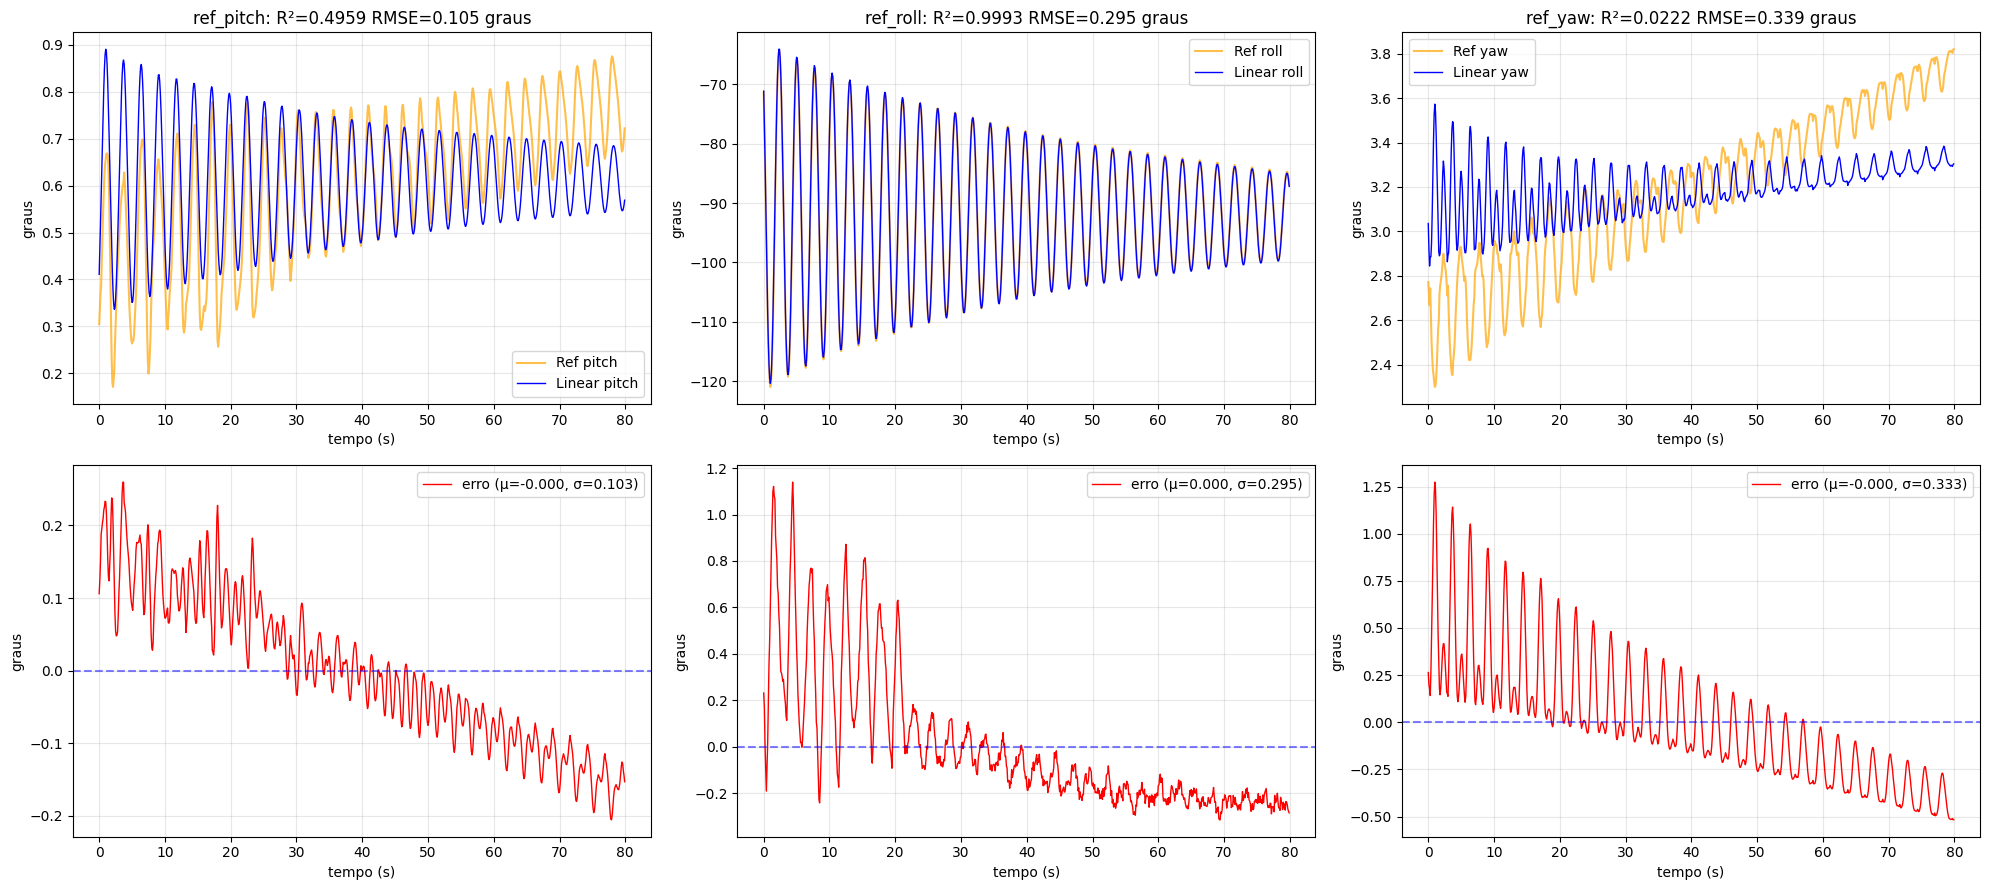

In [13]:
fit.display()
fit.plot()

# BACKUP DOS PARÂMETROS
- Cada linha de `params` é um ângulo da referência: $ref = pitch \cdot M_{pitch} + roll \cdot M_{roll} + yaw \cdot M_{yaw} + bias$

In [ ]:
os.makedirs('Backup', exist_ok=True)
saved  = [name for name in os.listdir('Backup') if name.startswith('model_')]    # O target.csv TEMPORÁRIO TAMBÉM MORA NO Backup
index  = len(saved) + 1

output = f'Backup/model_{index}'
os.makedirs(output, exist_ok=True)

results = {
    'model':   'linear_fit',
    'fuse':    fit.fuse,
    'params':  fit.info(),
    'metrics': fit.get(),
    'K_CV':    LinearFit.K_CV,
    'dataset': {'path': DATASET, 'samples': len(df), 'dt': float(dt), 'xCols': xCols, 'yCols': yCols}
}

pd.Series(results).to_json(f'{output}/info.json', indent=4)
print(output)
results

# SALVANDO O MODELO
- Ângulos calibrados ao lado dos da referência (`_ref`)

In [ ]:
attitude = full[['time', 'static']].copy()
yModel   = full[xCols].to_numpy() @ fit.M.T + fit.B    # O AJUSTE APLICADO TAMBÉM AO REPOUSO, QUE A ANÁLISE PRECISA

for i, xCol in enumerate(xCols):
    attitude[xCol]          = yModel[:, i]
    attitude[f'{xCol}_ref'] = full[yCols[i]]

record = {
    'strategy': results['model'],
    'backup':   f'Model/LinearFit/{output}',
    'targets':  xCols,
    'metrics':  fit.get()
}

os.makedirs(RESULTS, exist_ok=True)
attitude.to_csv(f'{RESULTS}/model.csv', index=None)
pd.Series(record).to_json(f'{RESULTS}/model.json', indent=4)
print(f'{RESULTS}/model.csv')
attitude

# EXPORTANDO PARA O FIRMWARE
- `config.h` do modelo leva a matriz e o viés; o `config.h` do `processing` diz qual modelo o firmware compila
- Quem exportar por último é quem roda no MRU, do mesmo jeito que o `model.csv` do teste

In [14]:
FIRMWARE = '../../../Hardware/Embedded/Main/objects/processing'
STAMP    = f'{datetime.date.today():%d/%m/%Y}'

matrix = ',\n\t'.join('{' + ', '.join(f'{value:.8f}f' for value in row) + '}' for row in fit.M)
bias   = ', '.join(f'{value:.8f}f' for value in fit.B)

header = f'''#ifndef LINEAR_CONFIG_H
#define LINEAR_CONFIG_H

// GERADO POR Calibration/Model/LinearFit/1 - Model.ipynb EM {STAMP}
#define LINEAR_NAME "linear_fit"

static const float LINEAR_M[3][3] = {{
\t{matrix}
}};    // linha = angulo calibrado, coluna = angulo do sensor: {', '.join(xCols)}

static const float LINEAR_B[3] = {{{bias}}};

#endif
'''

select = f'''#ifndef PROCESSING_CONFIG_H
#define PROCESSING_CONFIG_H
#include "models/linear/index.h"

// GERADO POR Calibration/Model/LinearFit/1 - Model.ipynb EM {STAMP}
using ProcessingModel = LinearModel;

#endif
'''

os.makedirs(f'{FIRMWARE}/models/linear', exist_ok=True)
open(f'{FIRMWARE}/models/linear/config.h', 'w').write(header)
open(f'{FIRMWARE}/config.h', 'w').write(select)

print(f'{FIRMWARE}/models/linear/config.h')
print(header)

../../../Hardware/Embedded/Main/objects/processing/models/linear/config.h
#ifndef LINEAR_CONFIG_H
#define LINEAR_CONFIG_H

// GERADO POR Calibration/Model/LinearFit/1 - Model.ipynb EM 22/09/2026
#define LINEAR_NAME "linear_fit"

static const float LINEAR_M[3][3] = {
	{0.06479649f, 0.00000000f, 0.00000000f},
	{0.00000000f, 1.00494025f, 0.00000000f},
	{0.00000000f, 0.00000000f, 0.53541830f}
};    // linha = angulo calibrado, coluna = angulo do sensor: pitch, roll, yaw

static const float LINEAR_B[3] = {0.50969706f, -89.29141042f, 1.46362145f};

#endif

